In [1]:
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [2]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

In [4]:
x_train[0].shape

(28, 28)

In [5]:
classes = {0: 'T-shirt/top',
1: 'Trouser',
2: 'Pullover',
3: 'Dress',
4: 'Coat',
5: 'Sandal',
6: 'Shirt',
7: 'Sneaker',
8: 'Bag',
9: 'Ankle boot'}

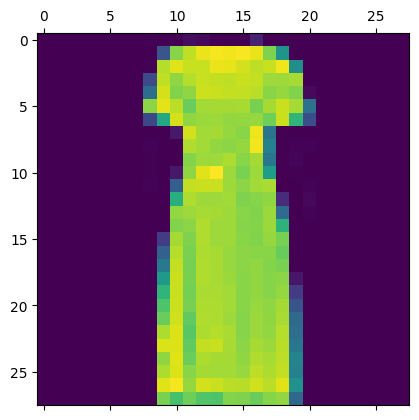

In [6]:
plt.matshow(x_train[50])

In [7]:
classes[y_train[50]]

'Dress'

In [8]:
# (batch_size, rows, columns, channels)
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1],x_train.shape[2], 1))
# X_ train = x_train.reshape((60000, 28,28, 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1],
x_test. shape [2] ,1))
# x_test = x_test.reshape((10000, 28,28,1))
x_train. shape

(60000, 28, 28, 1)

In [9]:
model = Sequential()
model.add(Conv2D(32,(3,3),input_shape=(28,28,1),strides=(2,2),padding='same',activation='relu'))#padding="valid"
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(loss='SparseCategoricalCrossentropy',optimizer=Adam(),metrics=['accuracy'])

In [15]:
hist=trained_history.history

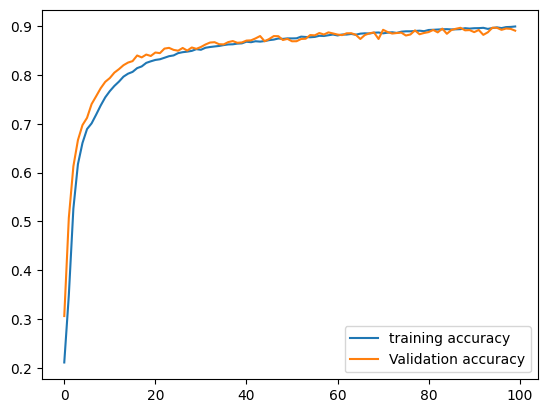

In [16]:
plt.plot(hist['accuracy'],label='training accuracy')
plt.plot(hist['val_accuracy'],label='Validation accuracy')
plt.legend()

In [11]:
trained_history=model.fit(x_train,y_train,batch_size=1000,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.1647 - loss: 11.3400 - val_accuracy: 0.3063 - val_loss: 1.8079
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3135 - loss: 1.8355 - val_accuracy: 0.5074 - val_loss: 1.4031
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4948 - loss: 1.4146 - val_accuracy: 0.6128 - val_loss: 1.0485
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6050 - loss: 1.0808 - val_accuracy: 0.6665 - val_loss: 0.8606
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6531 - loss: 0.9100 - val_accuracy: 0.6972 - val_loss: 0.7693
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6881 - loss: 0.8074 - val_accuracy: 0.7121 - val_loss: 0.7078
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6989 - loss: 0.7521 - val_accuracy: 0.7402 - val_loss: 0.6622
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7164 - loss: 0.7078 - val_accuracy: 0

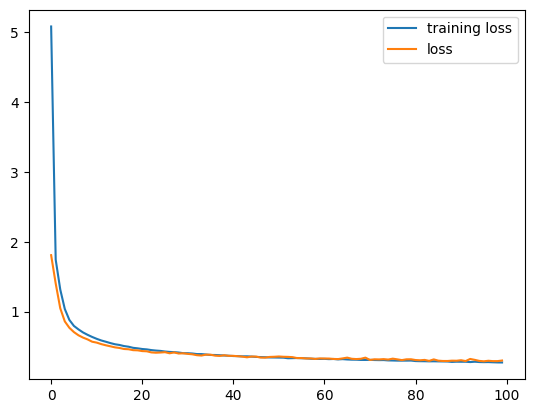

In [17]:
plt.plot(hist['loss'],label='training loss')
plt.plot(hist['val_loss'],label='loss')
plt.legend()

In [18]:
import numpy as np
def predict(index):
    plt.imshow(x_test[index])
    pred_image=x_test[index].reshape(1,28,28,1)
    pred_prob=model.predict(pred_image)
    pred_class=np.argmax(pred_prob)
    print('original class:',classes[y_test[index]])
    print('predicted class:',classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
original class: Bag
predicted class: Bag


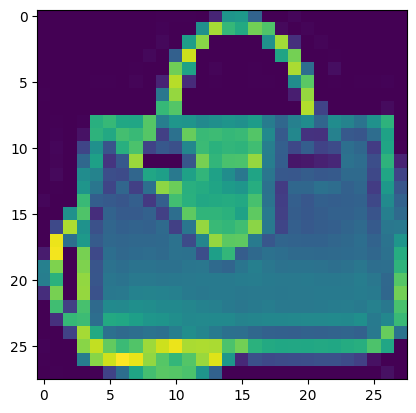

In [19]:
predict(126)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
original class: T-shirt/top
predicted class: T-shirt/top


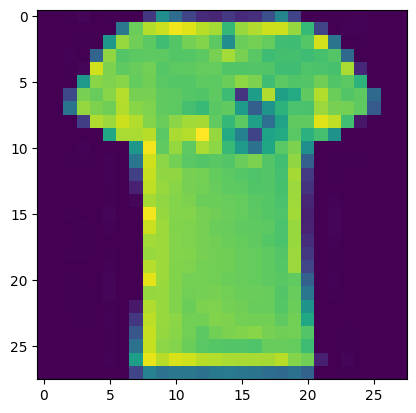

In [20]:
predict(1260)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
original class: Trouser
predicted class: Trouser


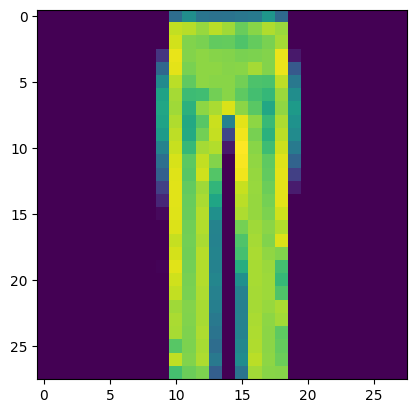

In [21]:
predict(5670)